# Подготовка данных

Здесь я подготовил данные для дальнейшего анализа и дашборда.

Сначала загрузил все таблицы (orders, users, products итд), посмотрел на их структуру и размер.  
Дальше привёл данные в нормальный вид: убрал дубликаты, перевёл даты в datetime, проверил пропуски.

Отдельно проверил цены, в данных встречались некорректные значения, их поправил.  
Также добавил категорию рейтинга, чтобы потом было удобнее анализировать отзывы.

После этого сделал небольшой EDA, чтобы понять распределения и посмотреть на выбросы.

В конце отфильтровал заказы по нужному периоду и сохранил итоговый датасет, с которым дальше работаю в SQL и дашборде.

Загружаю таблицу: orders
orders: 505400 строк, 5 колонок
Загружаю таблицу: order_items
order_items: 1516751 строк, 5 колонок
Загружаю таблицу: products
products: 52100 строк, 7 колонок
Загружаю таблицу: users
users: 111300 строк, 7 колонок
Загружаю таблицу: categories
categories: 1800 строк, 3 колонок
Загружаю таблицу: transactions
transactions: 811200 строк, 5 колонок
Загружаю таблицу: reviews
reviews: 310100 строк, 6 колонок

Проверяю данные перед анализом
orders: найдено 0 дубликатов
order_items: найдено 0 дубликатов
products: найдено 0 дубликатов
users: найдено 0 дубликатов
categories: найдено 0 дубликатов
transactions: найдено 0 дубликатов
reviews: найдено 0 дубликатов
Дубликатов не обнаружено
products: исправлено 0 некорректных цен

orders — пропуски:
order_id        0
buyer_id        0
order_date      0
status          0
total_amount    0
dtype: int64

order_items — пропуски:
order_item_id          0
order_id               0
product_id             0
quantity               0
pric

,price,stock_quantity
count,52100.000000,52100.000000
mean,506.569939,500.620461
std,285.605499,287.761399
min,10.020000,0.000000
25%,260.072500,254.000000
50%,507.810000,502.000000
75%,754.180000,747.000000
max,999.990000,1000.000000


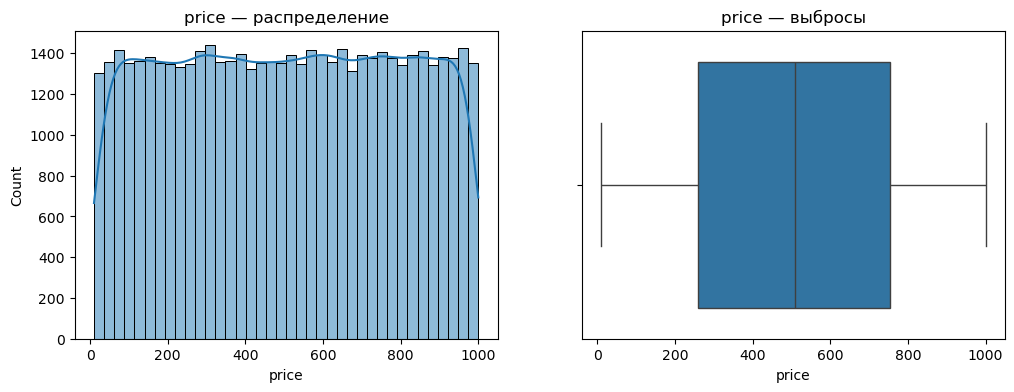

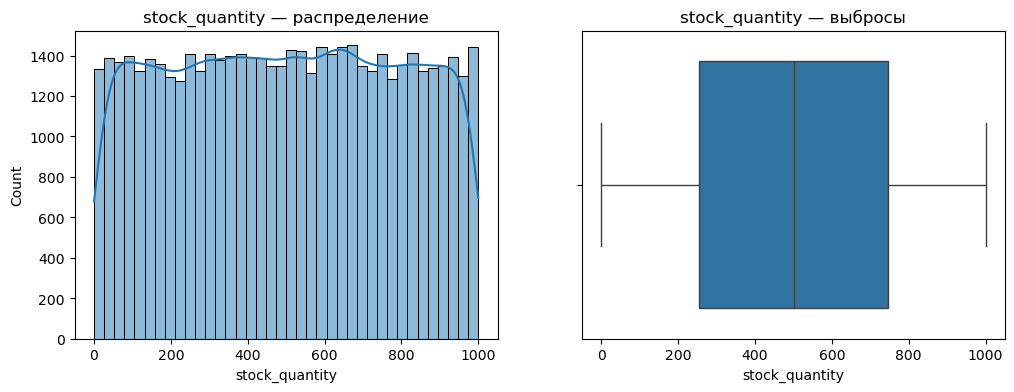


Корреляция price и stock_quantity:


,price,stock_quantity
price,1.000000,0.000815
stock_quantity,0.000815,1.000000



Датасет готов: exported_csv\orders_filtered.csv
Размер: 246456 строк, 5 колонок


In [1]:
# --- 1. Загрузка данных ---

import pandas as pd


def load_table(table_name):
    print(f"Загружаю таблицу: {table_name}")
    df = pd.read_csv(f"{table_name}.csv")
    print(f"{table_name}: {df.shape[0]} строк, {df.shape[1]} колонок")
    return df

tables = ['orders', 'order_items', 'products', 'users', 'categories', 'transactions', 'reviews']

# загружаю все таблицы
data = {}
for tbl in tables:
    data[tbl] = load_table(tbl)


# Предобработка 

print("\nПроверяю данные перед анализом")

# смотрю на дубликаты и сразу убираю их при необходимости
total_dups = 0
for name, df in data.items():
    dups = df.duplicated().sum()
    total_dups += dups
    print(f"{name}: найдено {dups} дубликатов")
    
    if dups > 0:
        df.drop_duplicates(inplace=True)

if total_dups == 0:
    print("Дубликатов не обнаружено")


# привожу даты к datetime, чтобы с ними можно было работать дальше
data['orders']['order_date'] = pd.to_datetime(data['orders']['order_date'], errors='coerce')
data['reviews']['review_date'] = pd.to_datetime(data['reviews']['review_date'], errors='coerce')
data['transactions']['transaction_date'] = pd.to_datetime(data['transactions']['transaction_date'], errors='coerce')
data['users']['registration_date'] = pd.to_datetime(data['users']['registration_date'], errors='coerce')


# проверяю цены — иногда встречаются отрицательные значения
neg_prices = data['products'][data['products']['price'] < 0].shape[0]

if neg_prices > 0:
    data['products'].loc[data['products']['price'] < 0, 'price'] = 0

print(f"products: исправлено {neg_prices} некорректных цен")


# смотрю на пропуски, чтобы понимать качество данных
for name, df in data.items():
    print(f"\n{name} пропуски:")
    print(df.isna().sum())


# добавляю категорию рейтинга 
def categorize_rating(r):
    if r >= 4.5:
        return 'High'
    elif r >= 4:
        return 'Medium'
    else:
        return 'Low'

data['reviews']['rating_category'] = data['reviews']['rating'].apply(categorize_rating)

print("reviews: добавил столбец rating_category")


#EDA
import matplotlib.pyplot as plt
import seaborn as sns

def eda(df, columns):
    print(f"\nСмотрю распределения: {columns}")
    display(df[columns].describe())
    
    for col in columns:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        
        sns.histplot(df[col].dropna(), kde=True, ax=axs[0])
        axs[0].set_title(f"{col} — распределение")
        
        sns.boxplot(x=df[col], ax=axs[1])
        axs[1].set_title(f"{col} — выбросы")
        
        plt.show()


eda(data['products'], ['price', 'stock_quantity'])

#проверяю, есть ли связь между ценой и количеством
corr = data['products'][['price', 'stock_quantity']].corr()
print("\nКорреляция price и stock_quantity:")
display(corr)


# выгрузка

import os

output_dir = 'exported_csv'
os.makedirs(output_dir, exist_ok=True)

# беру только нужный период
orders_filtered = data['orders'][
    (data['orders']['order_date'] >= '2025-01-01') &
    (data['orders']['order_date'] <= '2025-06-01')
]

orders_path = os.path.join(output_dir, 'orders_filtered.csv')
orders_filtered.to_csv(orders_path, sep=";", index=False)

print(f"\nДатасет готов: {orders_path}")
print(f"Размер: {orders_filtered.shape[0]} строк, {orders_filtered.shape[1]} колонок")